In [1]:
# Disable GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

In [2]:
import os
import sys
import glob
import math
import pickle
import ctypes

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

import seaborn as sns

import tensorflow as tf
from tensorflow.keras import utils

from sklearn.metrics import r2_score

from functools import partial
from multiprocessing import Pool
from joblib import Parallel, delayed
from pathlib import Path

from IPython.display import Image, display

import bayesflow as bf
import mvct_comp_functions_or as prior_simulator_functions

2026-05-17 08:16:48.428931: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 08:16:48.445147: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 08:16:48.445170: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 08:16:48.445182: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-17 08:16:48.448926: I tensorflow/core/platform/cpu_feature_g

In [3]:
# Helper function to pass variable N as shared context for model comparison
def variable_n_obs():
    n_obs = prior_simulator_functions.random_num_obs()
    return {'n_obs' : n_obs}

# Custom configurator to handle variable n_obs in model comparison
default_config = bf.configuration.DefaultModelComparisonConfigurator(num_models=4)

def variable_n_obs_configurator(forward_dict):
    config = default_config(forward_dict)
    batch_size = config['model_indices'].shape[0]
    config['direct_conditions'] = np.zeros((batch_size, 1), dtype=np.float32) + np.sqrt(forward_dict['n_obs'])
    return config

# Generative Model

In [4]:
# Generative model
PARAM_NAMES = ['t0', 'st0', 'zr', 'v1',  'v2', 'a', 'alpha', 'szr', 'sv']
PARAM_LABELS = [r"$t_0$", r"$s_{t_0}$", r"$z_r$", r"$v_{1}$", r"$v_{0}$", r"$a$", r"$\alpha$",
               r"$s_{z_r}$", r"$s_{v}$"]
MODEL_NAMES = ["DM_st0", "LFM_st0", "DM_all", "LFM_all"]
MODEL_LABELS = ["Simple DM", "Simple LFM", "Full DM", "Full LFM"]

# Neural networks
NUM_EPOCHS = 125
NUM_ITERATIONS_PER_EPOCH = 10000
BATCH_SIZE = 32
SUMMARY_NET_SETTINGS = {
    "summary_dim" : 16, 
    "num_dense_s1" : 3,
    "num_dense_s2" : 3,
    "num_dense_s3" : 3,
    "num_dense_equivariant" : 3
}
NUM_VAL_SAMPLES = 2000
NUM_ENSEMBLE_MEMBERS = 2

# Global
s = "no_deadline"
NUM_STUDIES = 2
SCENARIOS = ["tukeysides2_critfast1", #Tukey 1.5, fixed RT cutoff
             "tukeysides2_critfast0" #Tukey only
            ]
MY_NAME = "mvct_mod_comp_4m_" + str(NUM_EPOCHS) + "ep"
PRESIM_PATH = ""
NUM_PROCESSES = 25 #os.cpu_count()
FIG_ROOT_PATH = "mvct/figures/add/"
os.makedirs(FIG_ROOT_PATH, exist_ok=True)
MY_DPI = 600

print(MY_NAME)

mvct_mod_comp_4m_125ep


In [5]:
#t0, st0, zr, v0, v1, a, alpha, szr, sv
prior_simulator_functions.levy_prior(fix_alpha=True,
                                     fix_st0=False,
                                     fix_szr=False, fix_sv=False, batch_size=2)

array([[ 2.6765542e+00,  7.8219146e-01,  3.4515759e-01, -7.1857196e-01,
         7.8847611e-01,  7.5415173e+00,  2.0000000e+00,  3.5211977e-01,
         7.2330022e-01],
       [ 1.1074075e+00,  2.0710479e-03,  6.4186889e-01,  2.1709603e-01,
        -3.7457192e-01,  6.6619081e+00,  2.0000000e+00,  3.6777234e-01,
         5.5619925e-01]], dtype=float32)

In [6]:
# Prior functions
dm_prior_st0 = bf.simulation.Prior(batch_prior_fun=
                                 partial(prior_simulator_functions.levy_prior, 
                                         fix_alpha = True,
                                         fix_st0 = False,
                                         fix_szr = True, 
                                         fix_sv = True),
                                 param_names=PARAM_NAMES)
dm_prior_all = bf.simulation.Prior(batch_prior_fun=
                                 partial(prior_simulator_functions.levy_prior, 
                                         fix_alpha = True,
                                         fix_st0 = False,
                                         fix_szr = False, fix_sv = False),
                                 param_names=PARAM_NAMES)
levy_prior_st0 = bf.simulation.Prior(batch_prior_fun=
                                 partial(prior_simulator_functions.levy_prior, 
                                         fix_alpha = False,
                                         fix_st0 = False,
                                         fix_szr = True, fix_sv = True),
                                 param_names=PARAM_NAMES)
levy_prior_all = bf.simulation.Prior(batch_prior_fun=
                                 partial(prior_simulator_functions.levy_prior, 
                                         fix_alpha = False,
                                         fix_st0 = False,
                                         fix_szr = False, fix_sv = False),
                                 param_names=PARAM_NAMES)

# Simulator functions
if s == "deadline":
    simulator = bf.simulation.Simulator(batch_simulator_fun=
                                        partial(prior_simulator_functions.batch_simulator, 
                                                deadline=True))
else:
    simulator = bf.simulation.Simulator(batch_simulator_fun=
                                        partial(prior_simulator_functions.batch_simulator, 
                                                deadline=False))

# Generative models
MODEL_NAMES = ["DM_st0", "LFM_st0", "DM_all", "LFM_all"]
dm_st0 = bf.simulation.GenerativeModel(prior=dm_prior_st0, 
                                          simulator=simulator, name=MODEL_NAMES[0])
levy_st0 = bf.simulation.GenerativeModel(prior=levy_prior_st0, 
                                          simulator=simulator, name=MODEL_NAMES[1])
dm_all = bf.simulation.GenerativeModel(prior=dm_prior_all, 
                                          simulator=simulator, name=MODEL_NAMES[2])
levy_all = bf.simulation.GenerativeModel(prior=levy_prior_all, 
                                          simulator=simulator, name=MODEL_NAMES[3])
meta_model = bf.simulation.MultiGenerativeModel([dm_st0, levy_st0, 
                                                 dm_all, levy_all],
                                               shared_context_gen=variable_n_obs) 

INFO:root:Performing 2 pilot runs with the DM_st0 model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 9)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 344, 2)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Performing 2 pilot runs with the LFM_st0 model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 9)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 304, 2)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Performing 2 pilot runs with the DM_all model..

In [7]:
def setup_network(checkpoint_path, 
                  summary_net_settings=SUMMARY_NET_SETTINGS,
                  generative_model=meta_model, 
                  configurator=variable_n_obs_configurator,
                  learning_rate=0.0001 
                 ):
    
    tf.keras.backend.clear_session()

    summary_net = bf.networks.DeepSet(
        summary_dim = summary_net_settings["summary_dim"],
        num_dense_s1 = summary_net_settings["num_dense_s1"],
        num_dense_s2 = summary_net_settings["num_dense_s2"],
        num_dense_s3 = summary_net_settings["num_dense_s3"],
        num_equiv = summary_net_settings["num_dense_equivariant"]
    )

    inference_net = bf.inference_networks.PMPNetwork(num_models=4, num_dense=5, dropout=False)
    amortizer = bf.amortizers.AmortizedModelComparison(inference_net, summary_net)
    
    trainer = bf.trainers.Trainer(amortizer=amortizer, 
                                  generative_model=generative_model,
                                  configurator=configurator, 
                                  checkpoint_path=checkpoint_path, 
                                  default_lr=learning_rate,
                                  memory=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=
                                     tf.keras.optimizers.schedules.CosineDecay(
                                         learning_rate, NUM_ITERATIONS_PER_EPOCH*NUM_EPOCHS))
    
    return amortizer, trainer, optimizer

# Neural Network Training

## Pre-Simulation

In [8]:
def f(x, presim_path):
    file_path = os.path.join(presim_path, f'presim_file_{x}.pkl')
    with open(file_path, 'wb+') as file:
        for k in range(NUM_ITERATIONS_PER_EPOCH):
            presim_res = meta_model(BATCH_SIZE)
            pickle.dump(presim_res, file)

def multipickle_loader(file_path):
    sim_dicts = []
    with open(file_path, 'rb') as f:
        try:
            while True:
                sim_dicts.append(pickle.load(f))
        except EOFError:
            pass
    return sim_dicts

In [9]:
if __name__ == '__main__':
    FULL_PRESIM_PATH = os.path.join(PRESIM_PATH, MY_NAME)
    if not os.path.exists(FULL_PRESIM_PATH):
        os.makedirs(FULL_PRESIM_PATH)
        with Pool(processes=NUM_PROCESSES) as pool:
            presim_function = partial(f, presim_path=FULL_PRESIM_PATH)
            pool.map(presim_function, range(NUM_EPOCHS))

## Training Phase

2026-05-17 08:16:50.726174: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-17 08:16:50.726190: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: UKFPHPSY-C0821
2026-05-17 08:16:50.726192: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: UKFPHPSY-C0821
2026-05-17 08:16:50.726226: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 575.57.8
2026-05-17 08:16:50.726235: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  575.57.08  Release Build  (dvs-builder@U22-I3-H04-01-5)  Sat May 24 07:03:13 UTC 2025
GCC version:  gcc version 13.3.0 (Ubuntu 

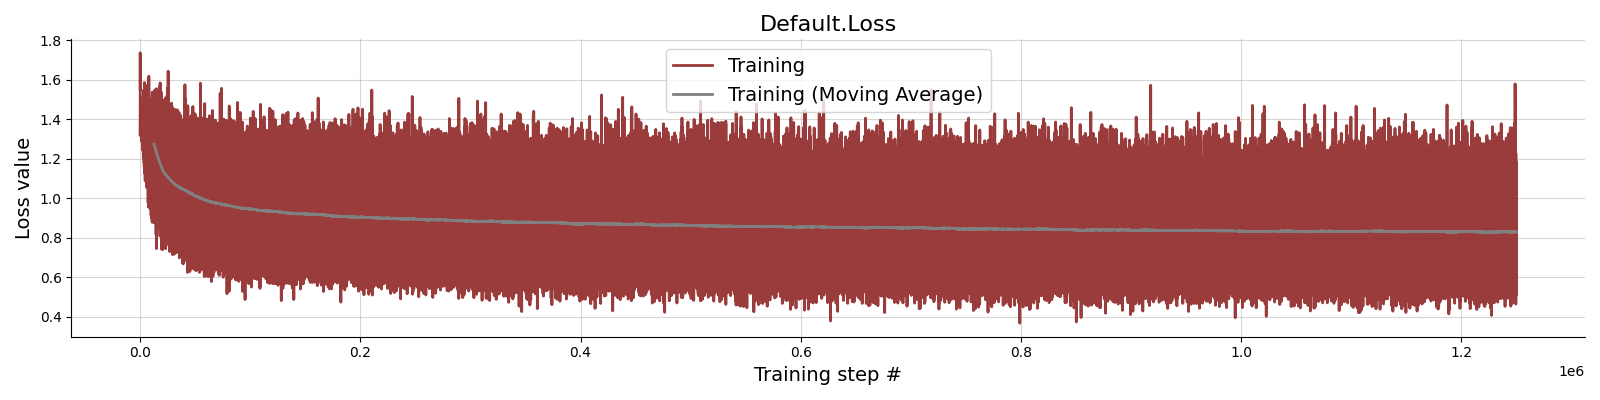

INFO:root:Loaded loss history from checkpoint_mvct_mod_comp_4m_125ep/net2/history_125.pkl.
INFO:root:Loaded simulation memory from checkpoint_mvct_mod_comp_4m_125ep/net2/memory.pkl
INFO:root:Networks loaded from checkpoint_mvct_mod_comp_4m_125ep/net2/ckpt-125
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


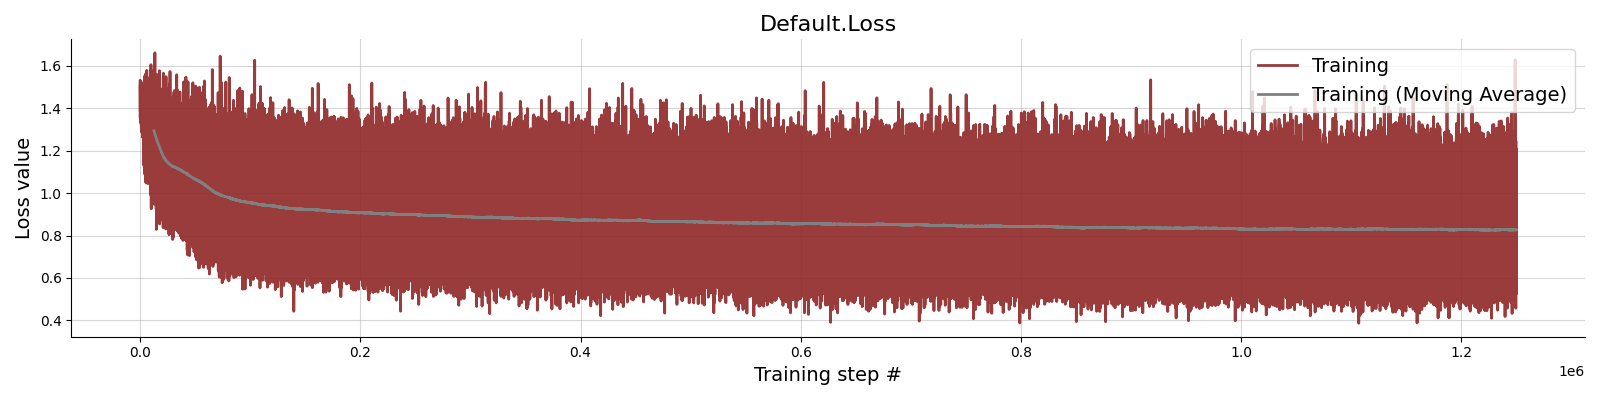

In [10]:
for network in range(NUM_ENSEMBLE_MEMBERS):
    amortizer, trainer, optimizer = setup_network(checkpoint_path=f"checkpoint_{MY_NAME}/net{network+1}")
    png_path = f"{FIG_ROOT_PATH}/losses_4m_net{network + 1}.png"
    
    if os.path.exists(png_path):
        display(Image(filename=png_path))
        continue
        
    if not os.path.exists(f"checkpoint_{MY_NAME}/net{network+1}"):
        losses = trainer.train_from_presimulation(FULL_PRESIM_PATH,
                                                  optimizer=optimizer,
                                                  reuse_optimizer=True,
                                                  custom_loader=multipickle_loader)
    
    diag_plot = bf.diagnostics.plot_losses(trainer.loss_history.get_plottable(), moving_average=True)
    diag_plot.savefig(png_path)

## Network Validation

In [11]:
def save_data(data, file_path):
    with open(file_path, "wb") as f:
        pickle.dump(data, f)

def load_data(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f)

In [12]:
VAL_ROOT_PATH = "mvct/validation"
os.makedirs(VAL_ROOT_PATH, exist_ok=True)

for network in range(NUM_ENSEMBLE_MEMBERS):
    SIM_INDICES_FILE = f"{VAL_ROOT_PATH}/sim_indices_{MY_NAME}_net{network+1}.pkl"
    SIM_PRED_FILE = f"{VAL_ROOT_PATH}/sim_pred_{MY_NAME}_net{network+1}.pkl"

    if all(os.path.exists(file) for file in [SIM_INDICES_FILE, SIM_PRED_FILE]):
        print(f"Data already exists for Network {network+1}, namely\n",
            SIM_INDICES_FILE, "\n", SIM_PRED_FILE)
    else:
        print("generating new data...")
        amortizer, trainer, optimizer = setup_network(checkpoint_path=f"checkpoint_{MY_NAME}/net{network+1}")
        sim_data = meta_model(NUM_VAL_SAMPLES)
        sim_data_transformed = variable_n_obs_configurator(sim_data)
        sim_indices = sim_data_transformed["model_indices"]
        sim_pred = amortizer(sim_data_transformed)
        print("saving data...")
        save_data(sim_indices, SIM_INDICES_FILE)
        save_data(sim_pred, SIM_PRED_FILE)
        print("data saved successfully")

Data already exists for Network 1, namely
 mvct/validation/sim_indices_mvct_mod_comp_4m_125ep_net1.pkl 
 mvct/validation/sim_pred_mvct_mod_comp_4m_125ep_net1.pkl
Data already exists for Network 2, namely
 mvct/validation/sim_indices_mvct_mod_comp_4m_125ep_net2.pkl 
 mvct/validation/sim_pred_mvct_mod_comp_4m_125ep_net2.pkl



--- Network 1 ---


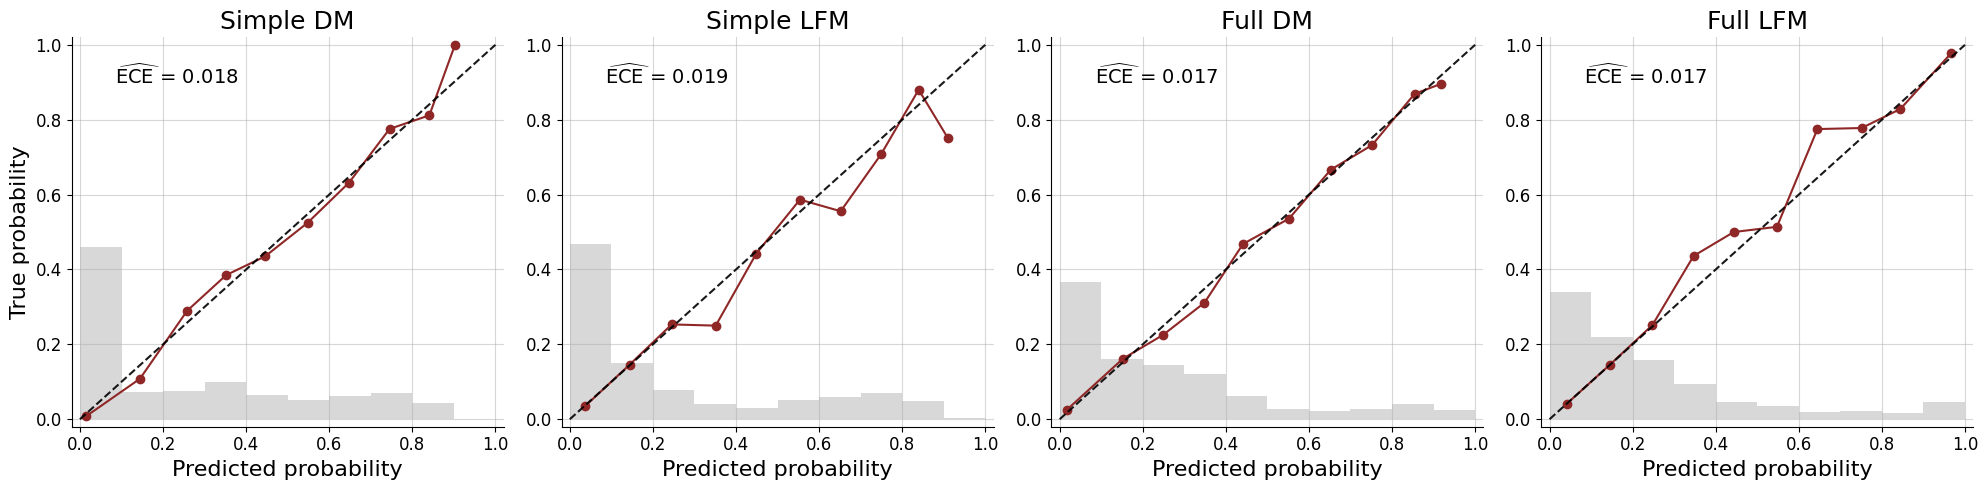


--- Network 2 ---


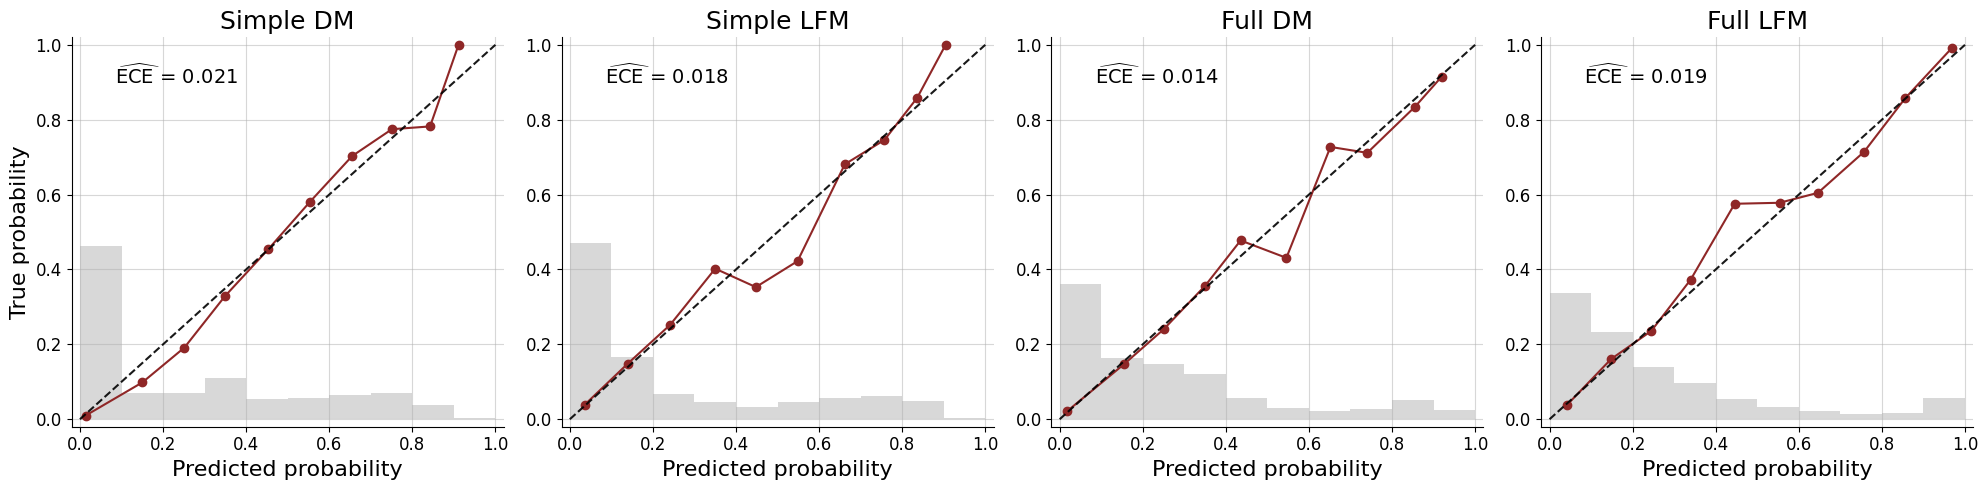

In [13]:
for network in range(NUM_ENSEMBLE_MEMBERS):
    SIM_INDICES_FILE = f"{VAL_ROOT_PATH}/sim_indices_{MY_NAME}_net{network+1}.pkl"
    SIM_PRED_FILE = f"{VAL_ROOT_PATH}/sim_pred_{MY_NAME}_net{network+1}.pkl"
    sim_indices = load_data(SIM_INDICES_FILE)
    sim_pred = load_data(SIM_PRED_FILE)
    bf.diagnostics.plot_calibration_curves(true_models=sim_indices,
                                           pred_models=sim_pred,
                                           model_names=MODEL_LABELS,
                                           #fig_size=(9, 4.5)
                                          )
    #plt.savefig(f"{FIG_ROOT_PATH}/calibration_net{network+1}.png", 
    #            dpi=MY_DPI, bbox_inches="tight")
    print(f"\n--- Network {network + 1} ---")
    plt.show()


--- Network 1 ---


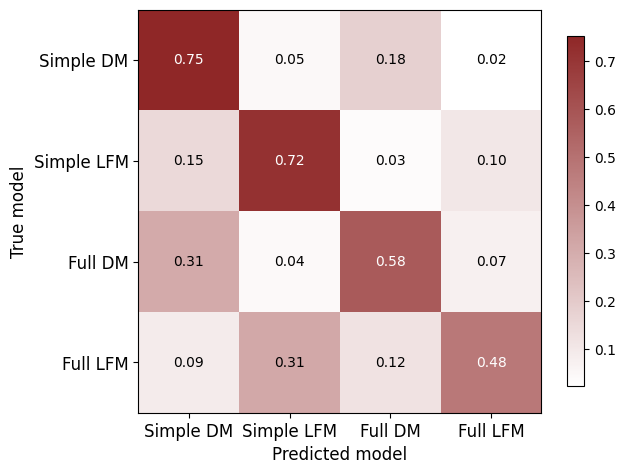


--- Network 2 ---


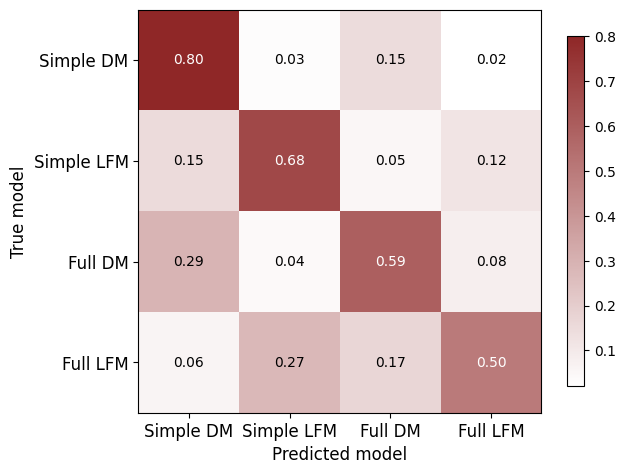

In [14]:
for network in range(NUM_ENSEMBLE_MEMBERS):
    SIM_INDICES_FILE = f"{VAL_ROOT_PATH}/sim_indices_{MY_NAME}_net{network+1}.pkl"
    SIM_PRED_FILE = f"{VAL_ROOT_PATH}/sim_pred_{MY_NAME}_net{network+1}.pkl"
    sim_indices = load_data(SIM_INDICES_FILE)
    sim_pred = load_data(SIM_PRED_FILE)
    conf_matrix = bf.diagnostics.plot_confusion_matrix(true_models=sim_indices, 
                                                       pred_models=sim_pred,
                                                       model_names=MODEL_LABELS,
                                                       fig_size=(6.5, 6.5),
                                                       title=False
                                                      )
    #plt.savefig(f"{FIG_ROOT_PATH}/confusion_net{network+1}.png", 
    #            dpi=MY_DPI, bbox_inches="tight")
    print(f"\n--- Network {network + 1} ---")
    plt.show()


--- Network 1 ---


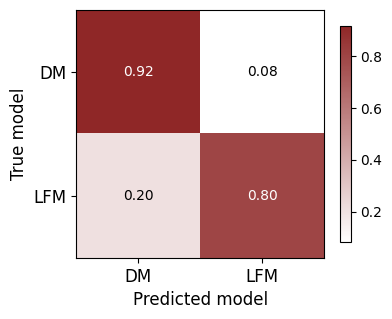


--- Network 2 ---


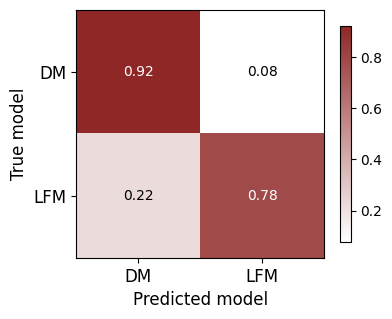

In [15]:
FAMILY_LABELS = ["DM", "LFM"]
DM_INDICES  = [0, 2]
LFM_INDICES = [1, 3]

def to_family_probs(sim_pred):
    probs = np.array(sim_pred)
    p_dm  = probs[:, DM_INDICES].sum(axis=1, keepdims=True)
    p_lfm = probs[:, LFM_INDICES].sum(axis=1, keepdims=True)
    out = np.concatenate([p_dm, p_lfm], axis=1)
    return out

def to_onehot(indices, n_classes=2):
    out = np.zeros((len(indices), n_classes))
    out[np.arange(len(indices)), indices] = 1
    return out

def to_family_indices(sim_indices):
    idx = np.argmax(np.array(sim_indices), axis=1)  
    return np.where(np.isin(idx, LFM_INDICES), 1, 0)  
    
# --- Family-level confusion matrices ---
for network in range(NUM_ENSEMBLE_MEMBERS):
    SIM_INDICES_FILE = f"{VAL_ROOT_PATH}/sim_indices_{MY_NAME}_net{network+1}.pkl"
    SIM_PRED_FILE = f"{VAL_ROOT_PATH}/sim_pred_{MY_NAME}_net{network+1}.pkl"
    sim_indices = load_data(SIM_INDICES_FILE)
    sim_pred = load_data(SIM_PRED_FILE)

    fam_indices_onehot = to_onehot(to_family_indices(sim_indices))
    fam_pred = to_family_probs(sim_pred)

    bf.diagnostics.plot_confusion_matrix(true_models=fam_indices_onehot,
                                         pred_models=fam_pred,
                                         model_names=FAMILY_LABELS,
                                         fig_size=(4, 4),
                                         title=False)
    #plt.savefig(f"{FIG_ROOT_PATH}/confusion_family_net{network+1}.png",
    #            dpi=MY_DPI, bbox_inches="tight")
    print(f"\n--- Network {network + 1} ---")
    plt.show()

# Network Application

In [16]:
# Load empirical data
DATA_ROOT_PATH = f"mvct/behav_demo_data/prepared2/"
ESTIM_ROOT_PATH = "mvct/estimates_mod_comp"
os.makedirs(ESTIM_ROOT_PATH, exist_ok=True)

In [17]:
for network in range(NUM_ENSEMBLE_MEMBERS):
    for study in range(NUM_STUDIES):
        for scenario in SCENARIOS:
            estimates_dir = f'{ESTIM_ROOT_PATH}/{scenario}'
            if not os.path.exists(estimates_dir):
                os.makedirs(estimates_dir)
                
            estimates_path = f'{estimates_dir}/{MY_NAME}_study{study+1}_net{network+1}.csv'
            
            if not os.path.exists(estimates_path):  
                amortizer, trainer, optimizer = setup_network(
                    checkpoint_path=f"checkpoint_{MY_NAME}/net{network+1}"
                )
                data_path = os.path.join(DATA_ROOT_PATH, f'study{study+1}_tukey1.5_{scenario}/')
                datafiles = glob.glob(data_path + '*.csv') 
                preds = []   
                
                for datafile in datafiles:
                    raw_data = pd.read_csv(datafile)
                    data = np.expand_dims(raw_data.to_numpy(), 0)
                    data = np.delete(data, 2, axis=2) #Delete half column
                    thisdict = {"summary_conditions": data, 
                                "direct_conditions": np.zeros((1, 1), dtype=np.float32) + np.sqrt(data.shape[1])}
                    samples = amortizer.posterior_probs(thisdict, to_numpy=True)
                    preds.append(samples)
                    
                preds = np.array(preds)[:, 0, :]
                df = pd.DataFrame(preds, columns=MODEL_NAMES)
                df['file'] = [os.path.basename(filepath) for filepath in datafiles]  
                df[['pp', 'condition', 'ans', 'att', 'acc']] = df['file'].str.extract(
                    r'pp(\d+)_(guess|control)_ans(\d+)_att(\d+)_acc(\d+)\.csv$'
                )
                df = df.astype({'att': int, 'acc': int})
                df.to_csv(estimates_path, index=False)
                
                print(f"Saved estimates to {estimates_path}")
            else:
                print(f"{estimates_path} already exists")

mvct/estimates_mod_comp/tukeysides2_critfast1/mvct_mod_comp_4m_125ep_study1_net1.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast0/mvct_mod_comp_4m_125ep_study1_net1.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast1/mvct_mod_comp_4m_125ep_study2_net1.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast0/mvct_mod_comp_4m_125ep_study2_net1.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast1/mvct_mod_comp_4m_125ep_study1_net2.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast0/mvct_mod_comp_4m_125ep_study1_net2.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast1/mvct_mod_comp_4m_125ep_study2_net2.csv already exists
mvct/estimates_mod_comp/tukeysides2_critfast0/mvct_mod_comp_4m_125ep_study2_net2.csv already exists


## Ensemble Agreement

In [18]:
def plot_ensemble_agreement(
    net1_estimates,
    net2_estimates,
    param_names=None,
    fig_size=None,
    label_fontsize=16,
    title_fontsize=18,
    metric_fontsize=16,
    tick_fontsize=12,
    add_corr=True,
    add_r2=True,
    color="#8f2727",
    n_col=None,
    n_row=None,
    xlabel="Network 1",
    ylabel="Network 2",
    study=None,
    **kwargs,
):
    """ Alters bf.diagnostics.plot_recovery to show the degree of agreement between two ensemble members."""

    n_params = net1_estimates.shape[-1]
    if param_names is None:
        param_names = [f"$\\theta_{{{i}}}$" for i in range(1, n_params + 1)]

    if n_row is None and n_col is None:
        n_row = int(np.ceil(n_params / 6))
        n_col = int(np.ceil(n_params / n_row))
    elif n_row is None and n_col is not None:
        n_row = int(np.ceil(n_params / n_col))
    elif n_row is not None and n_col is None:
        n_col = int(np.ceil(n_params / n_row))

    if fig_size is None:
        fig_size = (int(4 * n_col), int(4 * n_row))
    f, axarr = plt.subplots(n_row, n_col, figsize=fig_size)

    if n_col > 1 or n_row > 1:
        axarr_it = axarr.flat
    else:
        axarr_it = [axarr]

    for i, ax in enumerate(axarr_it):
        if i >= n_params:
            break

        _ = ax.scatter(net1_estimates[:, i], net2_estimates[:, i], alpha=0.5, color=color, **kwargs)

        lower = min(net1_estimates[:, i].min(), net2_estimates[:, i].min())
        upper = max(net1_estimates[:, i].max(), net2_estimates[:, i].max())
        eps = (upper - lower) * 0.1
        ax.set_xlim([lower - eps, upper + eps])
        ax.set_ylim([lower - eps, upper + eps])
        ax.plot(
            [ax.get_xlim()[0], ax.get_xlim()[1]],
            [ax.get_ylim()[0], ax.get_ylim()[1]],
            color="black",
            alpha=0.9,
            linestyle="dashed",
        )

        if add_r2:
            r2 = r2_score(net1_estimates[:, i], net2_estimates[:, i])
            ax.text(
                0.1,
                0.9,
                "$R^2$ = {:.3f}".format(r2),
                horizontalalignment="left",
                verticalalignment="center",
                transform=ax.transAxes,
                size=metric_fontsize,
            )
        if add_corr:
            corr = np.corrcoef(net1_estimates[:, i], net2_estimates[:, i])[0, 1]
            ax.text(
                0.1,
                0.8,
                "$r$ = {:.3f}".format(corr),
                horizontalalignment="left",
                verticalalignment="center",
                transform=ax.transAxes,
                size=metric_fontsize,
            )
        ax.set_title(param_names[i], fontsize=title_fontsize)

        # Prettify
        sns.despine(ax=ax)
        ax.grid(alpha=0.5)
        ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
        ax.tick_params(axis="both", which="minor", labelsize=tick_fontsize)


    bottom_row = axarr if n_row == 1 else axarr[0] if n_col == 1 else axarr[n_row - 1, :]
    for _ax in bottom_row:
        _ax.set_xlabel(xlabel, fontsize=label_fontsize)

    if n_row == 1:
        axarr[0].set_ylabel(ylabel, fontsize=label_fontsize)
    else:
        for _ax in axarr[:, 0]:
            _ax.set_ylabel(ylabel, fontsize=label_fontsize)

    for _ax in axarr_it[n_params:]:
        _ax.remove()

    annotation = "A" if study == 0 else "B"
    f.text(0.0, 0.975, annotation, fontsize=20, ha='left', fontweight='bold')

    f.tight_layout()
    return f


--- Study 1, tukeysides2_critfast1 ---


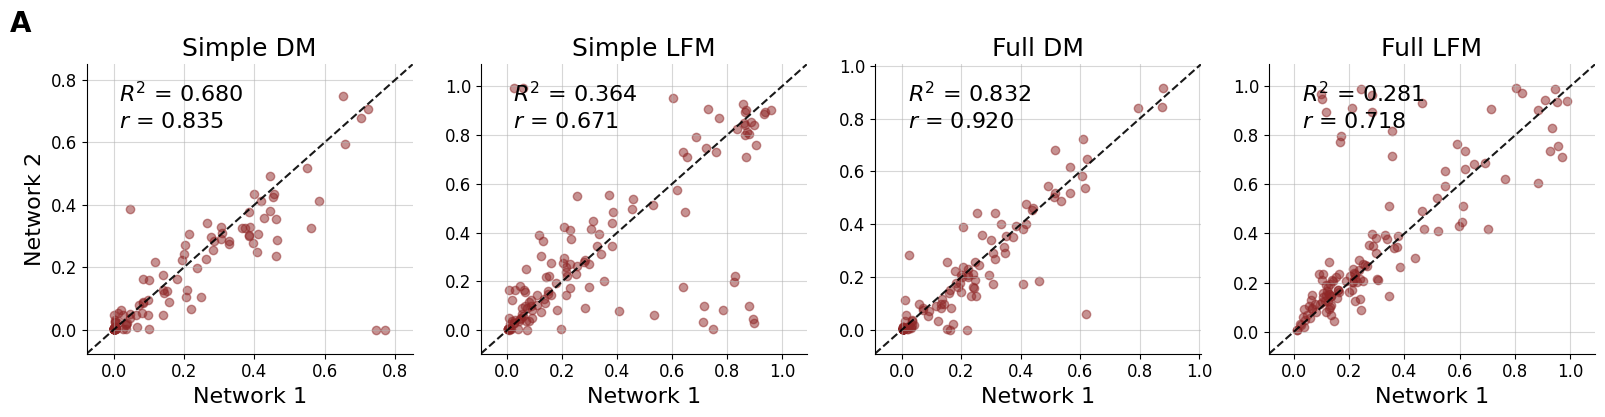


--- Study 2, tukeysides2_critfast1 ---


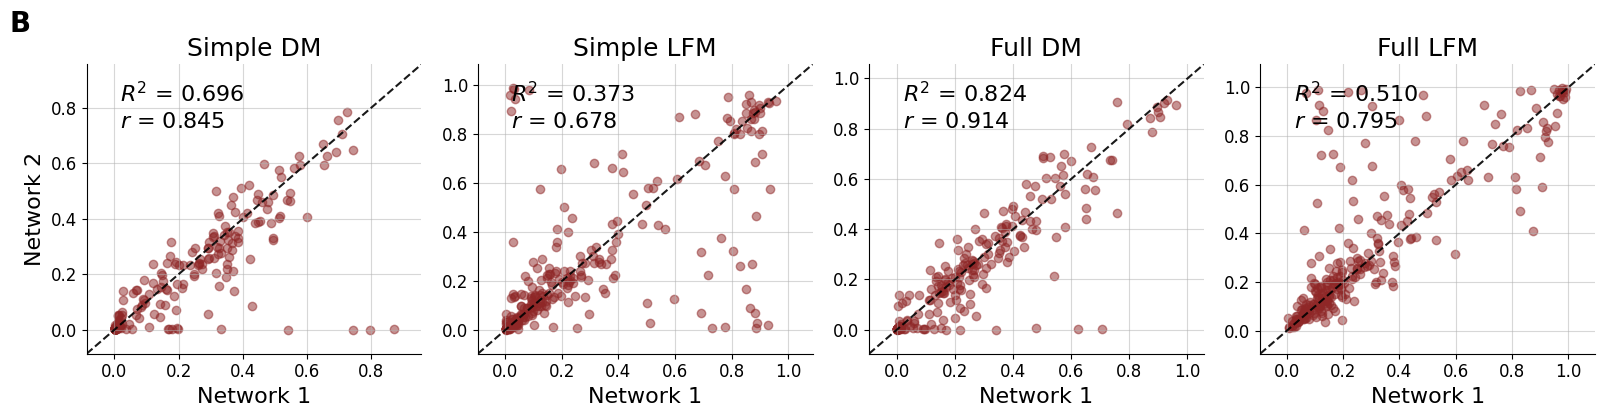


--- Study 1, tukeysides2_critfast0 ---


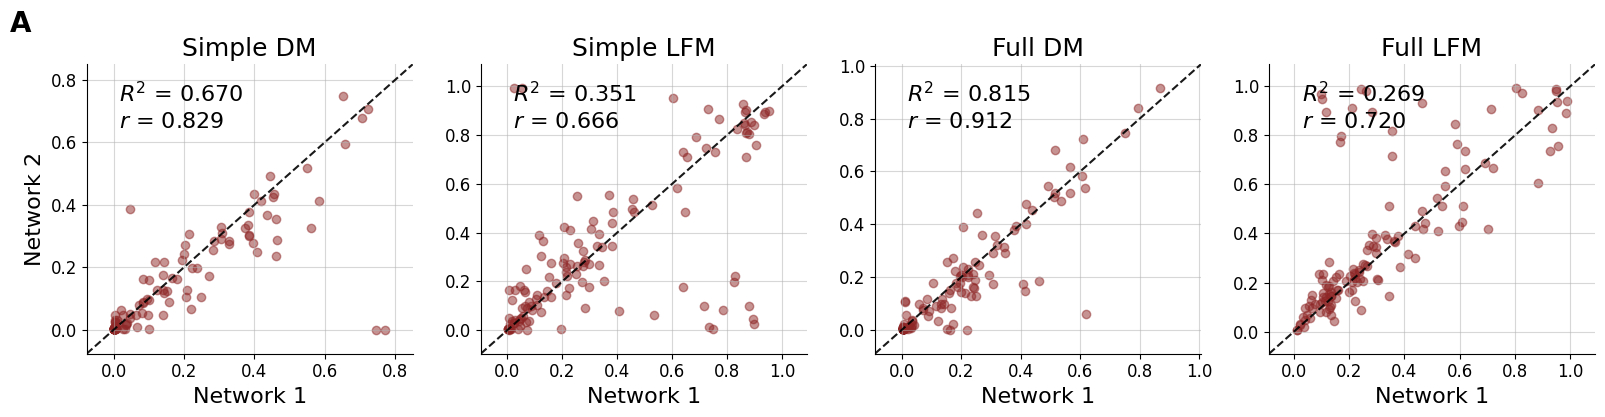


--- Study 2, tukeysides2_critfast0 ---


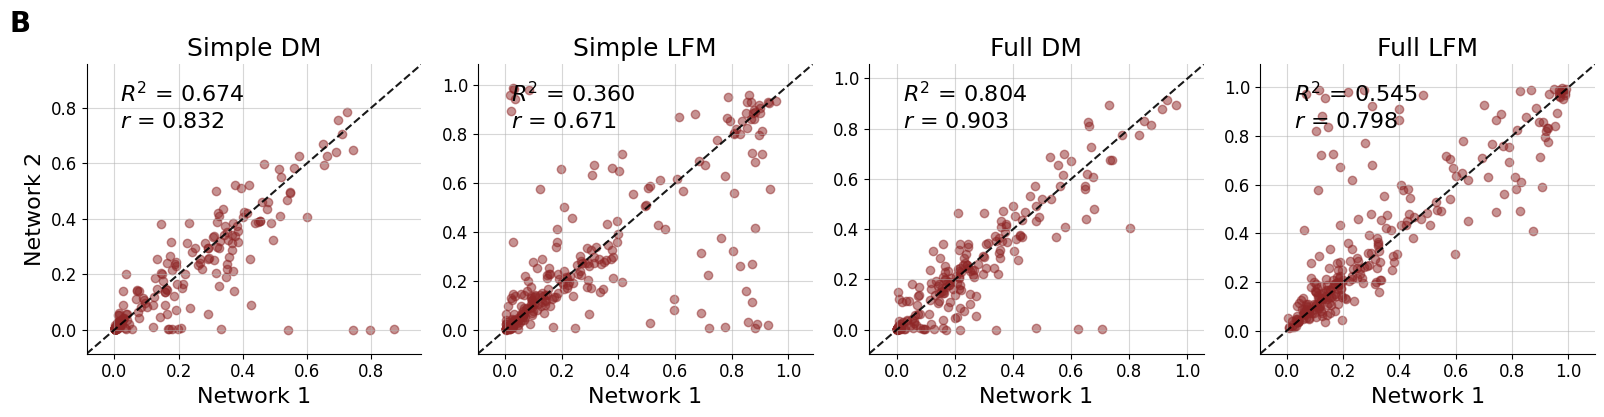

In [19]:
for scenario in SCENARIOS:
    for study in range(NUM_STUDIES):
        estimates_dir = f'{ESTIM_ROOT_PATH}/{scenario}'
        net1_pred = pd.read_csv(f'{estimates_dir}/{MY_NAME}_study{study+1}_net1.csv', index_col='pp')
        net2_pred = pd.read_csv(f'{estimates_dir}/{MY_NAME}_study{study+1}_net2.csv', index_col='pp')
        net1_pred = net1_pred[MODEL_NAMES]
        net2_pred = net2_pred[MODEL_NAMES]
        
        plot_ensemble_agreement(
                    net1_estimates=np.array(net1_pred), net2_estimates=np.array(net2_pred),
                    xlabel="Network 1", ylabel="Network 2", study=study,
                    param_names=MODEL_LABELS#, add_corr=False, add_r2=True
                )
        #plt.savefig(f"{FIG_ROOT_PATH}/agreement_{scenario}_study{study+1}.png", dpi=MY_DPI, bbox_inches="tight")
        print(f"\n--- Study {study + 1}, {scenario} ---")
        plt.show()


--- Study 1, tukeysides2_critfast1 ---


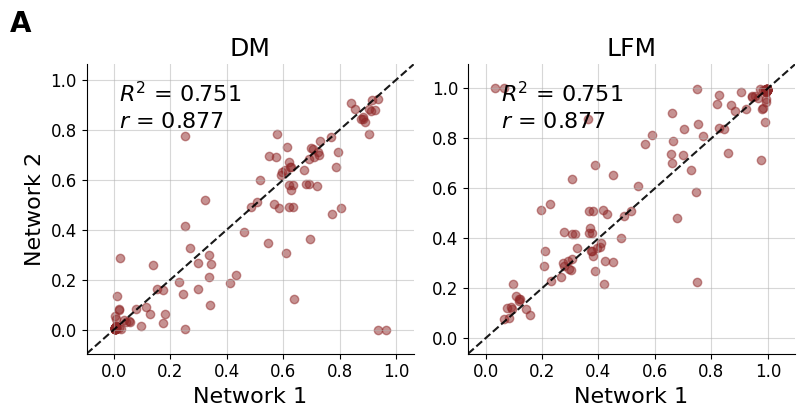


--- Study 2, tukeysides2_critfast1 ---


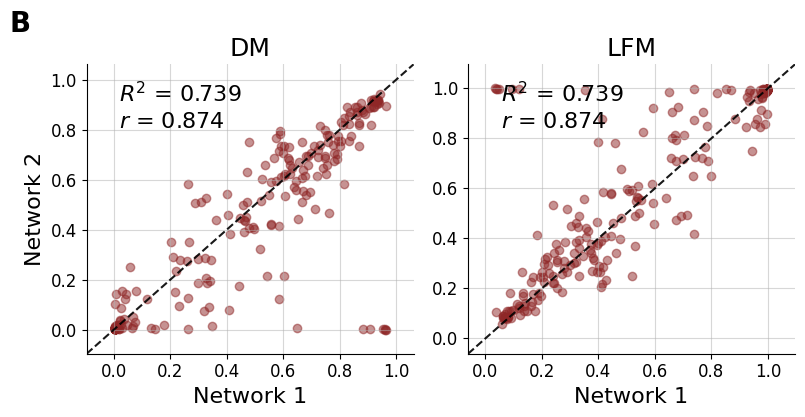


--- Study 1, tukeysides2_critfast0 ---


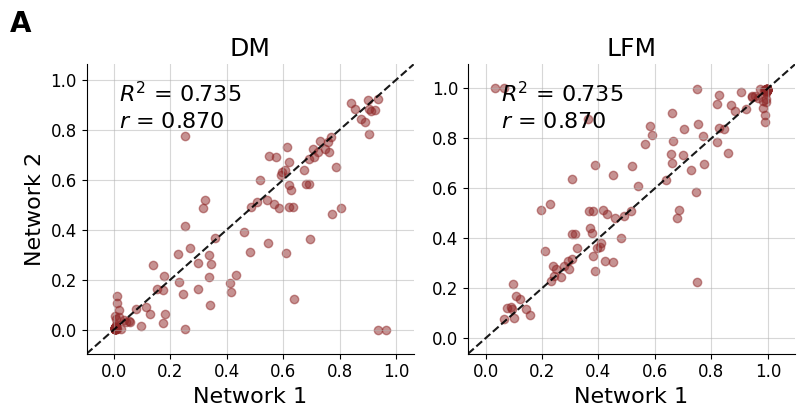


--- Study 2, tukeysides2_critfast0 ---


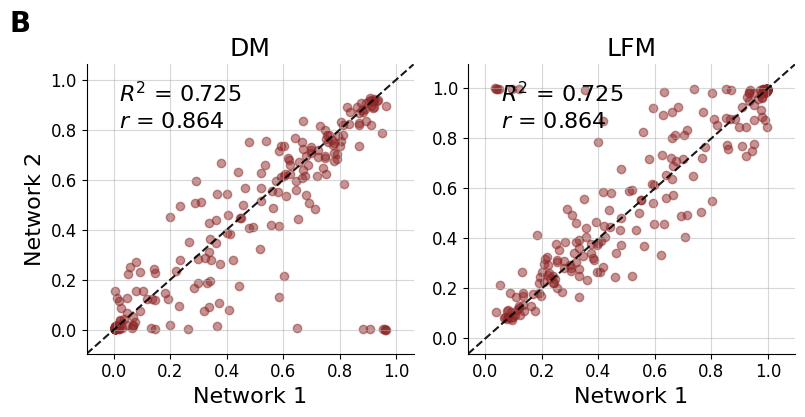

In [20]:
for scenario in SCENARIOS:
    for study in range(NUM_STUDIES):
        estimates_dir = f'{ESTIM_ROOT_PATH}/{scenario}'
        net1_pred_f = pd.read_csv(f'{estimates_dir}/{MY_NAME}_study{study+1}_net1.csv', index_col='pp')
        net2_pred_f = pd.read_csv(f'{estimates_dir}/{MY_NAME}_study{study+1}_net2.csv', index_col='pp')
        net1_pred_f = net1_pred_f[MODEL_NAMES]
        net2_pred_f = net2_pred_f[MODEL_NAMES]

        # Collapse to family level
        net1_family = np.stack([
            np.array(net1_pred_f)[: , DM_INDICES].sum(axis=1),
            np.array(net1_pred_f)[:, LFM_INDICES].sum(axis=1)
        ], axis=1)
        net2_family = np.stack([
            np.array(net2_pred_f)[:, DM_INDICES].sum(axis=1),
            np.array(net2_pred_f)[:, LFM_INDICES].sum(axis=1)
        ], axis=1)
    
        plot_ensemble_agreement(
            net1_estimates=net1_family,
            net2_estimates=net2_family,
            xlabel="Network 1", ylabel="Network 2", study=study,
            param_names=FAMILY_LABELS
        )
        #plt.savefig(f"{FIG_ROOT_PATH}/agreement_family_{scenario}_study{study+1}.png",
        #            dpi=MY_DPI, bbox_inches="tight")
        print(f"\n--- Study {study + 1}, {scenario} ---")
        plt.show()

## PMPs and BFs

In [21]:
def fmt(x, digits=2):
    return f"{x:.{digits}f}"

def fmt_no_leading_zero(x, digits=2):
    s = f"{x:.{digits}f}"
    if s.startswith("0"):
        s = s[1:]
    elif s.startswith("-0"):
        s = "-" + s[2:]
    return s

def odds_ratio_ci_from_counts(a, b, c, d, alpha=0.05, correction=0.5):
    a = float(a)
    b = float(b)
    c = float(c)
    d = float(d)

    if min(a, b, c, d) == 0:
        a += correction
        b += correction
        c += correction
        d += correction

    or_val = (a * d) / (b * c)
    log_or = math.log(or_val)
    se = math.sqrt(1 / a + 1 / b + 1 / d + 1 / c)

    z = 1.96 if abs(alpha - 0.05) < 1e-9 else stats.norm.ppf(1 - alpha / 2)

    ci_low = math.exp(log_or - z * se)
    ci_high = math.exp(log_or + z * se)
    return or_val, ci_low, ci_high

def compute_preference_counts(df, col_a, col_b, condition_col="condition", conditions=("control", "guess")):
    out = {}
    for cond in conditions:
        sub = df[df[condition_col] == cond]

        n_a = int((sub[col_a] > sub[col_b]).sum())
        n_b = int((sub[col_b] > sub[col_a]).sum())
        n_tie = int((sub[col_a] == sub[col_b]).sum())
        n_total = len(sub)

        out[cond] = {
            "n_a": n_a,
            "n_b": n_b,
            "n_tie": n_tie,
            "n_total": n_total,
            "pct_a": 100 * n_a / n_total,
            "pct_b": 100 * n_b / n_total,
            "pct_tie": 100 * n_tie / n_total
        }
    return out
    
def compute_preference_counts_overall(df, col_a, col_b):
    n_a = int((df[col_a] > df[col_b]).sum())
    n_b = int((df[col_b] > df[col_a]).sum())
    n_tie = int((df[col_a] == df[col_b]).sum())
    n_total = len(df)

    return {
        "n_a": n_a,
        "n_b": n_b,
        "n_tie": n_tie,
        "n_total": n_total,
        "pct_a": 100 * n_a / n_total,
        "pct_b": 100 * n_b / n_total,
        "pct_tie": 100 * n_tie / n_total
    }

MODEL_NAME_MAP = {
    "DM_st0": "Simple DM",
    "LFM_st0": "Simple LFM",
    "DM_all": "Full DM",
    "LFM_all": "Full LFM",
    "P_DM_family": "DM family",
    "P_LFM_family": "LFM family"
}

COMPARISONS = [
    {
        "analysis": "Simple LFM vs. simple DM",
        "type": "pairwise",
        "a_col": "LFM_st0",
        "b_col": "DM_st0",
        "a_label": "Simple LFM",
        "b_label": "Simple DM",
        "bf_direction": "LFM / DM"
    },
    {
        "analysis": "Simple LFM vs. full LFM",
        "type": "pairwise",
        "a_col": "LFM_st0",
        "b_col": "LFM_all",
        "a_label": "Simple LFM",
        "b_label": "Full LFM",
        "bf_direction": "Simple / Full"
    },
    {
        "analysis": "Family-level",
        "type": "family",
        "a_col": "P_LFM_family",
        "b_col": "P_DM_family",
        "a_label": "LFM family",
        "b_label": "DM family",
        "bf_direction": "LFM / DM"
        
    }
]

In [22]:
for scenario in SCENARIOS:
    for network in range(1):
        print(f"\n--- Network {network + 1}, {scenario} ---\n")
        a1_rows = []
        a2_rows = []
        a3_rows = []
        
        for study in range(NUM_STUDIES):
            estimates_dir = f'{ESTIM_ROOT_PATH}/{scenario}'
            df = pd.read_csv(f"{estimates_dir}/{MY_NAME}_study{study+1}_net{network+1}.csv", index_col="pp").drop(columns=["file", "ans", "att", "acc"], errors="ignore").copy()

            df["P_DM_family"] = df["DM_st0"] + df["DM_all"]
            df["P_LFM_family"] = df["LFM_st0"] + df["LFM_all"]
        
            #4-model PMPs
            for cond_label, cond_value in [("Control", "control"), ("Guessing", "guess")]:
                sub = df[df["condition"] == cond_value]
        
                for model_col in ["DM_st0", "LFM_st0", "DM_all", "LFM_all"]:
                    a1_rows.append(
                        {
                            "Study": study + 1,
                            "Group": cond_label,
                            "Analysis": "4-model",
                            "Model": MODEL_NAME_MAP[model_col],
                            "Mean": sub[model_col].mean(),
                            "SD": sub[model_col].std(),
                            "Median": sub[model_col].median()
                        }
                    )
                    
            #family
            for comp in COMPARISONS:
                analysis = comp["analysis"]
                a_col = comp["a_col"]
                b_col = comp["b_col"]
                a_label = comp["a_label"]
                b_label = comp["b_label"]
                bf_direction = comp["bf_direction"]
        
                bf_col = f"BF_{a_col}_vs_{b_col}"
                df[bf_col] = df[a_col] / df[b_col]
        
                if analysis == "Family-level":
                    for cond_label, cond_value in [("Control", "control"), ("Guessing", "guess")]:
                        sub = df[df["condition"] == cond_value]
                        for model_col, model_label in [(a_col, a_label), (b_col, b_label)]:
                            a1_rows.append(
                                {
                                    "Study": study + 1,
                                    "Group": cond_label,
                                    "Analysis": "Family-level",
                                    "Model": model_label,
                                    "Mean": sub[model_col].mean(),
                                    "SD": sub[model_col].std(),
                                    "Median": sub[model_col].median()
                                }
                            )
        
                counts = compute_preference_counts(df, a_col, b_col)
        
                a_guess = counts["guess"]["n_a"]
                b_guess = counts["guess"]["n_b"]
                a_control = counts["control"]["n_a"]
                b_control = counts["control"]["n_b"]
                or_val, ci_low, ci_high = odds_ratio_ci_from_counts(a_guess, b_guess, a_control, b_control)
                try:
                    fisher_table = [[a_guess, b_guess], [a_control, b_control]]
                    _, p_fisher = fisher_exact(fisher_table, alternative="two-sided")
                except Exception:
                    p_fisher = np.nan
        
                for cond_label, cond_value in [("Control", "control"), ("Guessing", "guess")]:
                    sub = df[df["condition"] == cond_value]
                    c = counts[cond_value]
                    a2_rows.append(
                        {
                            "Study": study + 1,
                            "Group": cond_label,
                            "Comparison": analysis,
                            "BF direction": bf_direction,
                            "Mean": sub[bf_col].mean(),
                            "SD": sub[bf_col].std(),
                            "Median": sub[bf_col].median(),
                            "n": c["n_a"],
                            "%": c["pct_a"],
                            "OR": or_val if cond_value == "control" else np.nan,
                            "95% CI": f"[{ci_low:.2f}, {ci_high:.2f}]" if cond_value == "control" else "",
                            "p": p_fisher if cond_value == "control" else np.nan
                        }
                    )
        
                c_all = compute_preference_counts_overall(df, a_col, b_col)
                a3_rows.append(
                    {
                        "Study": study + 1,
                        "Comparison": analysis,
                        "BF direction": bf_direction,
                        "Mean": df[bf_col].mean(),
                        "SD": df[bf_col].std(),
                        "Median": df[bf_col].median(),
                        "n (%)": f"{c_all['n_a']} ({c_all['pct_a']:.2f}%)",
                        "N total": c_all["n_total"]
                    }
                )

        table_a1 = pd.DataFrame(a1_rows)
        table_a2 = pd.DataFrame(a2_rows)
        table_a3 = pd.DataFrame(a3_rows)
        
        analysis_order_a1 = ["4-model", "Family-level"]
        comparison_order = ["Simple LFM vs. simple DM", "Simple LFM vs. full LFM", "Family-level"]
        model_order = ["Simple DM", "Simple LFM", "Full DM", "Full LFM", "DM family", "LFM family"]
        group_order = ["Control", "Guessing"]
        bf_direction_order = ["LFM / DM", "Simple / Full"]
        
        table_a1["Analysis"] = pd.Categorical(table_a1["Analysis"], categories=analysis_order_a1, ordered=True)
        table_a1["Group"] = pd.Categorical(table_a1["Group"], categories=group_order, ordered=True)
        table_a1["Model"] = pd.Categorical(table_a1["Model"], categories=model_order, ordered=True)
        
        table_a2["Comparison"] = pd.Categorical(table_a2["Comparison"], categories=comparison_order, ordered=True)
        table_a2["Group"] = pd.Categorical(table_a2["Group"], categories=group_order, ordered=True)
        table_a2["BF direction"] = pd.Categorical(table_a2["BF direction"], categories=bf_direction_order, ordered=True)
        
        table_a3["Comparison"] = pd.Categorical(table_a3["Comparison"], categories=comparison_order, ordered=True)
        table_a3["BF direction"] = pd.Categorical(table_a3["BF direction"], categories=bf_direction_order, ordered=True)

        table_a1 = table_a1.sort_values(["Study", "Group", "Analysis", "Model"]).reset_index(drop=True)
        table_a2 = table_a2.sort_values(["Study", "Group", "Comparison", "BF direction"]).reset_index(drop=True)
        table_a3 = table_a3.sort_values(["Study", "Comparison", "BF direction"]).reset_index(drop=True)
        
        table_a1_fmt = table_a1.copy()
        for col in ["Mean", "SD", "Median"]:
            table_a1_fmt[col] = table_a1_fmt[col].map(lambda x: fmt_no_leading_zero(x))
        
        table_a2_fmt = table_a2.copy()
        for col in ["Mean", "SD", "Median"]:
            table_a2_fmt[col] = table_a2_fmt[col].map(lambda x: fmt(x))
        table_a2_fmt["%"] = table_a2_fmt["%"].map(lambda x: f"{x:.2f}")
        table_a2_fmt["OR"] = table_a2_fmt["OR"].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
        table_a2_fmt["p"] = table_a2_fmt["p"].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
        
        table_a3_fmt = table_a3.copy()
        for col in ["Mean", "SD", "Median"]:
            table_a3_fmt[col] = table_a3_fmt[col].map(lambda x: fmt(x))
        
        display(table_a1_fmt)
        display(table_a2_fmt)
        display(table_a3_fmt)


--- Network 1, tukeysides2_critfast1 ---



,Study,Group,Analysis,Model,Mean,SD,Median
0,1,Control,4-model,Simple DM,.17,.23,.04
1,1,Control,4-model,Simple LFM,.32,.33,.18
2,1,Control,4-model,Full DM,.20,.22,.17
3,1,Control,4-model,Full LFM,.30,.26,.23
4,1,Control,Family-level,DM family,.38,.35,.30
5,1,Control,Family-level,LFM family,.62,.35,.70
6,1,Guessing,4-model,Simple DM,.16,.18,.09
7,1,Guessing,4-model,Simple LFM,.36,.31,.24
8,1,Guessing,4-model,Full DM,.17,.20,.13
9,1,Guessing,4-model,Full LFM,.31,.27,.21


,Study,Group,Comparison,BF direction,Mean,SD,Median,n,%,OR,95% CI,p
0,1,Control,Simple LFM vs. simple DM,LFM / DM,116.75,206.10,1.48,36,56.25,1.07,"[0.53, 2.15]",1.000
1,1,Control,Simple LFM vs. full LFM,Simple / Full,2.42,3.16,1.09,33,51.56,1.21,"[0.60, 2.42]",0.723
2,1,Control,Family-level,LFM / DM,65.85,102.34,2.36,36,56.25,1.21,"[0.60, 2.45]",0.720
3,1,Guessing,Simple LFM vs. simple DM,LFM / DM,111.88,188.53,2.15,37,57.81,,,
4,1,Guessing,Simple LFM vs. full LFM,Simple / Full,2.56,4.33,1.15,36,56.25,,,
5,1,Guessing,Family-level,LFM / DM,74.34,100.64,2.81,39,60.94,,,
6,2,Control,Simple LFM vs. simple DM,LFM / DM,90.60,173.24,1.24,69,53.08,0.94,"[0.58, 1.53]",0.901
7,2,Control,Simple LFM vs. full LFM,Simple / Full,2.17,3.74,0.74,59,45.38,1.28,"[0.79, 2.08]",0.385
8,2,Control,Family-level,LFM / DM,69.81,100.64,1.67,69,53.08,1.06,"[0.65, 1.73]",0.901
9,2,Guessing,Simple LFM vs. simple DM,LFM / DM,94.12,181.70,1.08,67,51.54,,,


,Study,Comparison,BF direction,Mean,SD,Median,n (%),N total
0,1,Simple LFM vs. simple DM,LFM / DM,114.32,196.75,1.94,73 (57.03%),128
1,1,Simple LFM vs. full LFM,Simple / Full,2.49,3.78,1.15,69 (53.91%),128
2,1,Family-level,LFM / DM,70.09,101.18,2.52,75 (58.59%),128
3,2,Simple LFM vs. simple DM,LFM / DM,92.36,177.19,1.09,136 (52.31%),260
4,2,Simple LFM vs. full LFM,Simple / Full,2.17,3.31,0.97,126 (48.46%),260
5,2,Family-level,LFM / DM,64.43,99.03,1.18,140 (53.85%),260



--- Network 1, tukeysides2_critfast0 ---



,Study,Group,Analysis,Model,Mean,SD,Median
0,1,Control,4-model,Simple DM,.17,.23,.04
1,1,Control,4-model,Simple LFM,.33,.33,.21
2,1,Control,4-model,Full DM,.19,.21,.16
3,1,Control,4-model,Full LFM,.31,.26,.24
4,1,Control,Family-level,DM family,.36,.34,.27
5,1,Control,Family-level,LFM family,.64,.34,.73
6,1,Guessing,4-model,Simple DM,.15,.17,.09
7,1,Guessing,4-model,Simple LFM,.37,.30,.27
8,1,Guessing,4-model,Full DM,.16,.19,.13
9,1,Guessing,4-model,Full LFM,.32,.26,.23


,Study,Group,Comparison,BF direction,Mean,SD,Median,n,%,OR,95% CI,p
0,1,Control,Simple LFM vs. simple DM,LFM / DM,116.41,206.11,2.07,37,57.81,1.22,"[0.60, 2.47]",0.718
1,1,Control,Simple LFM vs. full LFM,Simple / Full,2.42,3.17,1.06,32,50.00,1.29,"[0.64, 2.58]",0.595
2,1,Control,Family-level,LFM / DM,66.50,102.63,2.68,39,60.94,1.22,"[0.60, 2.51]",0.714
3,1,Guessing,Simple LFM vs. simple DM,LFM / DM,113.41,190.28,2.40,40,62.50,,,
4,1,Guessing,Simple LFM vs. full LFM,Simple / Full,2.50,3.96,1.15,36,56.25,,,
5,1,Guessing,Family-level,LFM / DM,75.01,99.67,2.96,42,65.62,,,
6,2,Control,Simple LFM vs. simple DM,LFM / DM,90.62,173.14,1.62,73,56.15,1.06,"[0.65, 1.74]",0.900
7,2,Control,Simple LFM vs. full LFM,Simple / Full,2.18,3.77,0.71,58,44.62,1.32,"[0.81, 2.15]",0.321
8,2,Control,Family-level,LFM / DM,70.16,100.00,2.74,76,58.46,1.07,"[0.65, 1.75]",0.900
9,2,Guessing,Simple LFM vs. simple DM,LFM / DM,96.08,184.81,1.37,75,57.69,,,


,Study,Comparison,BF direction,Mean,SD,Median,n (%),N total
0,1,Simple LFM vs. simple DM,LFM / DM,114.91,197.58,2.29,77 (60.16%),128
1,1,Simple LFM vs. full LFM,Simple / Full,2.46,3.57,1.15,68 (53.12%),128
2,1,Family-level,LFM / DM,70.76,100.85,2.96,81 (63.28%),128
3,2,Simple LFM vs. simple DM,LFM / DM,93.35,178.74,1.42,148 (56.92%),260
4,2,Simple LFM vs. full LFM,Simple / Full,2.16,3.32,0.95,125 (48.08%),260
5,2,Family-level,LFM / DM,65.20,99.21,1.94,154 (59.23%),260
